# E-Commerce Sales Analysis & Cohort Analysis

In [35]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [36]:
# Load dataset and Preview data

df = pd.read_csv("online_retail_II dataset.csv", encoding='ISO-8859-1')

print(df.shape)
df.head()

(541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [37]:
df.info() # Display dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [38]:
df.describe() # Summary statistics of numerical columns

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [39]:
df.isnull().sum() # Check missing values in each column

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [40]:
df = df.dropna(subset=['Customer ID']) #Remove Missing Customer IDs

In [41]:
df = df[~df['Invoice'].astype(str).str.startswith('C')] #Remove Cancelled Orders

In [42]:
df = df[df['Quantity'] > 0] # Remove negative or zero quantities

In [43]:
df = df[df['Quantity'] < 10000] # Remove extreme outliers in quantity

In [44]:
df = df[df['Price'] > 0] # Remove invalid price values

In [45]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M') #Convert Date

In [46]:
df['Revenue'] = df['Quantity'] * df['Price'] #Create Revenue Column

In [47]:
df.info() # Check cleaned dataset structure

<class 'pandas.core.frame.DataFrame'>
Index: 397883 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      397883 non-null  object        
 1   StockCode    397883 non-null  object        
 2   Description  397883 non-null  object        
 3   Quantity     397883 non-null  int64         
 4   InvoiceDate  397883 non-null  datetime64[ns]
 5   Price        397883 non-null  float64       
 6   Customer ID  397883 non-null  float64       
 7   Country      397883 non-null  object        
 8   Revenue      397883 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [48]:
df.isnull().sum() # Confirm no missing values remain

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [49]:
# Extract month and year features for time-based analysis

df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month

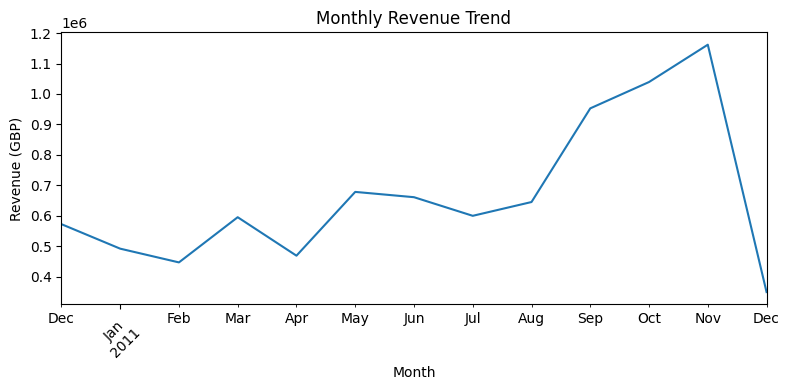

In [70]:
# Analyze monthly revenue trend

plt.figure(figsize=(8,4))
monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (GBP)")   

plt.xticks(rotation=45)       
plt.tight_layout()            

plt.show()

### Insight:
Revenue shows a strong increasing trend with a peak towards the end of the year, indicating seasonal demand during holiday periods.

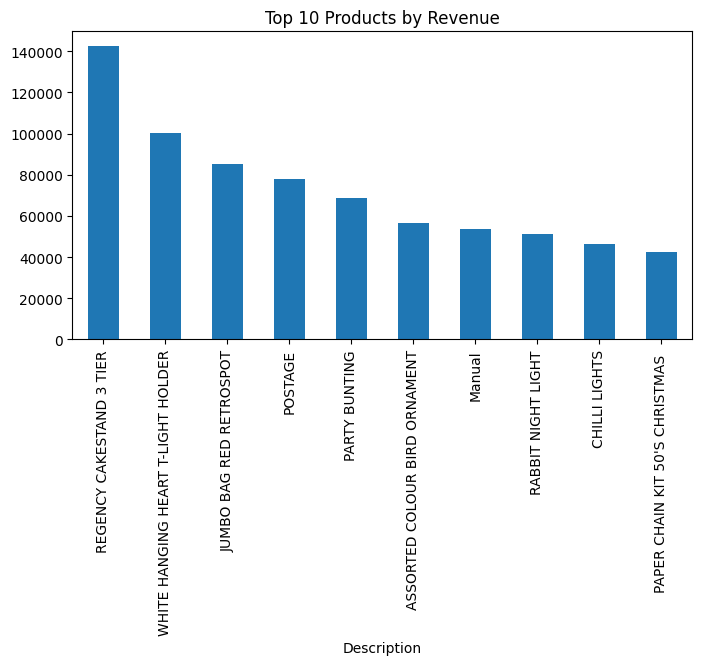

In [72]:
# Identify top 10 products by revenue

top_products = df.groupby('Description')['Revenue'] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

plt.figure(figsize=(8,4))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()

### Insight:
A small number of products contribute significantly to total revenue, indicating a skewed sales distribution.

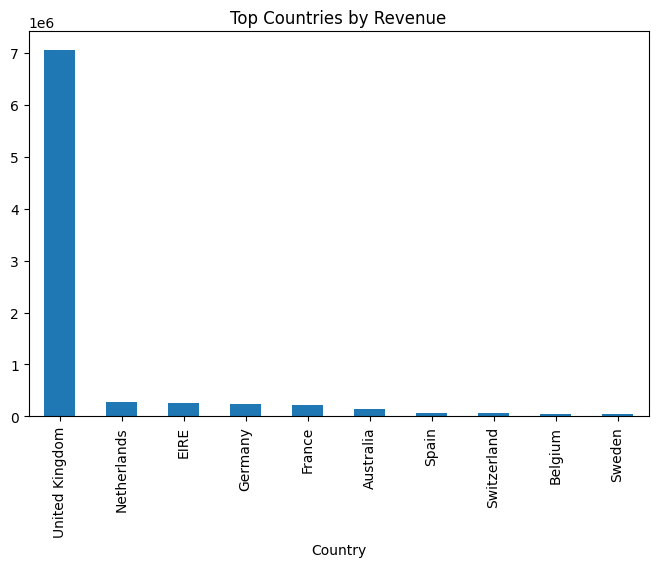

In [52]:
# Analyze revenue by country

country_sales = df.groupby('Country')['Revenue'] \
                 .sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

### Insight:
The United Kingdom dominates sales, suggesting the business primarily operates in the domestic market.

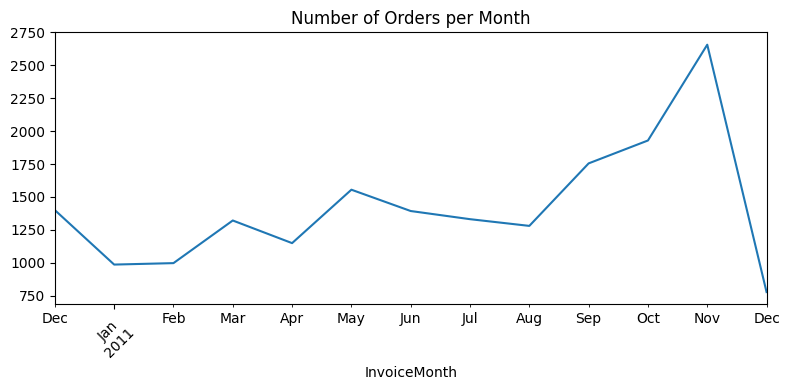

In [73]:
# Count number of unique orders per month

orders = df.groupby('InvoiceMonth')['Invoice'].nunique()

plt.figure(figsize=(8,4))
orders.plot()
plt.title("Number of Orders per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

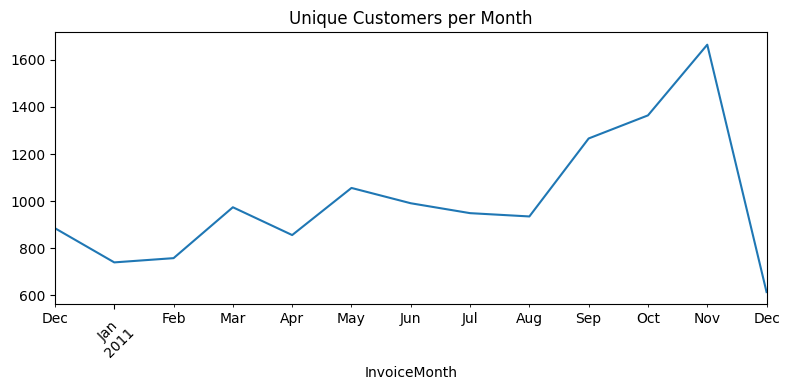

In [76]:
# Count unique customers per month

customers = df.groupby('InvoiceMonth')['Customer ID'].nunique()

plt.figure(figsize=(8,4))
customers.plot()
plt.title("Unique Customers per Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight (Customer Growth):
Both orders and customer count increase over time, showing business growth.

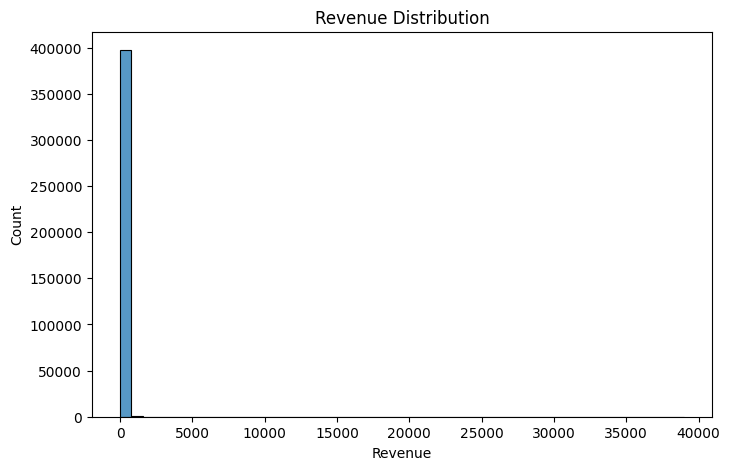

In [55]:
# Visualize revenue distribution

plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], bins=50)
plt.title("Revenue Distribution")
plt.show()

### Insight (Revenue Distribution):
Revenue is highly skewed, with most transactions being low value and few high-value purchases.

## Conclusion

The analysis reveals strong sales growth with clear seasonal trends, especially during year-end periods. A small number of products contribute significantly to total revenue, indicating a skewed sales distribution. The United Kingdom dominates the market, showing a strong domestic customer base. Additionally, the increasing number of orders and customers highlights consistent business growth. These insights can help in improving customer retention strategies and optimizing product offerings.

## Cohort Analysis

This section analyzes customer retention over time by grouping customers based on their first purchase month.

### Create Cohort Data

In [56]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M') #Create Invoice Month

In [57]:
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'] \
                      .transform('min')                           #Get First Purchase Month (Cohort Month)

In [58]:
df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n) #Create Cohort Index (Time Difference)

### Create Retention Table

In [59]:
#Group Data

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'] \
                .nunique() \
                .reset_index()

In [60]:
#Pivot Table

cohort_pivot = cohort_data.pivot(index='CohortMonth',
                                columns='CohortIndex',
                                values='Customer ID')

In [61]:
#Convert to Retention %

cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

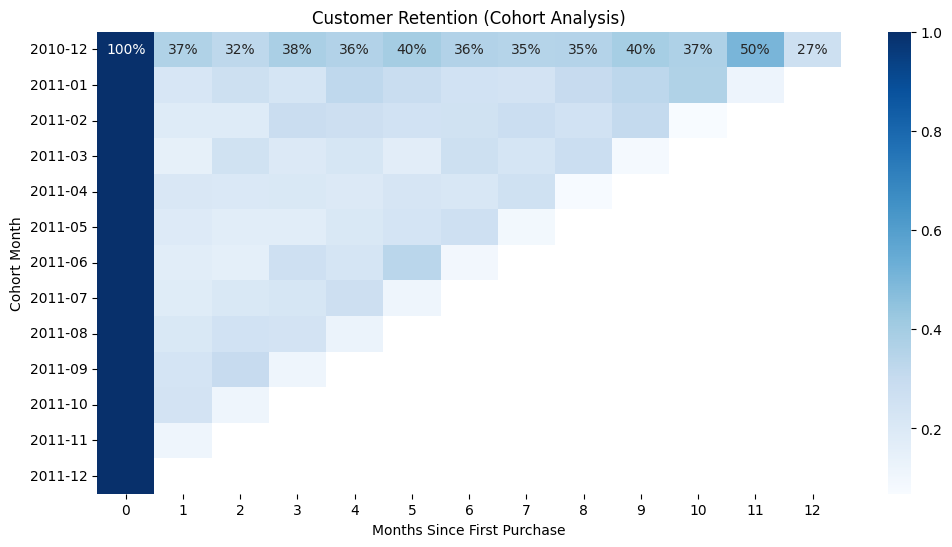

In [62]:
#Plot Cohort Heatmap

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap='Blues')
plt.title("Customer Retention (Cohort Analysis)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.show()

### Insight:
Customer retention decreases over time, with the highest retention in the first month. Some cohorts show better retention, indicating strong customer engagement during specific periods.

### COHORT RETENTION (LONG FORMAT)
Cohort data is converted into long format to enable flexible and dynamic visualization of customer retention in tools like Power BI.

In [63]:
# CONVERT TO LONG FORMAT

# Reset index for pivot table
cohort_long = retention.reset_index()

# Convert wide → long format
cohort_long = cohort_long.melt(
    id_vars=['CohortMonth'],
    var_name='CohortIndex',
    value_name='RetentionRate'
)

# Remove null values
cohort_long = cohort_long.dropna()

### RFM ANALYSIS
RFM analysis segments customers based on Recency, Frequency, and Monetary value to identify high-value and loyal customers.

In [64]:
# Create snapshot date (1 day after last transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   # Recency
    'Invoice': 'nunique',                                      # Frequency
    'Revenue': 'sum'                                           # Monetary
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [65]:
#CREATE RFM SCORES

# Assign scores (1–4 scale)

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Combine into RFM Score
rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

In [66]:
# CREATE CUSTOMER SEGMENTS
def segment_customer(score):
    if score >= 9:
        return 'High Value'
    elif score >= 6:
        return 'Mid Value'
    else:
        return 'Low Value'

rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

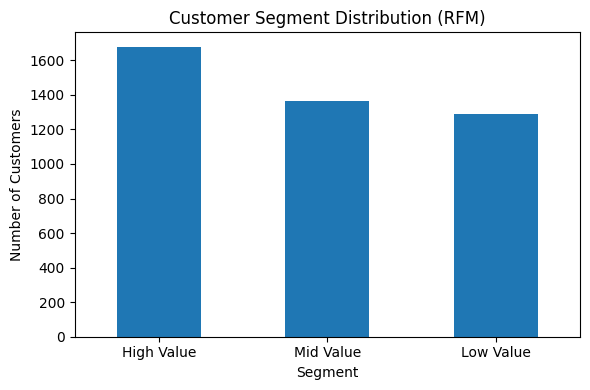

In [69]:
# Count customers per segment
segment_counts = rfm['Segment'].value_counts()

# Plot bar chart
plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar')

plt.title("Customer Segment Distribution (RFM)")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight:
The majority of customers fall into the mid and low value segments, while a smaller proportion are high-value customers.

Recommendation:
The business should focus on retaining high-value customers and converting mid-value customers into high-value customers through targeted marketing and loyalty programs.

In [68]:
#Export Data for Power BI

df.to_csv("final_cleaned_data.csv", index=False)
retention.to_csv("cohort_retention.csv")
rfm.to_csv("rfm_segments.csv", index=False)
cohort_long.to_csv("cohort_retention_long.csv", index=False)